<a href="https://colab.research.google.com/github/20240609-lab/Data-Science/blob/main/week14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/6_titanic_data.csv')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 데이터 프레임의 전반적인 정보 확인 (컬럼명, 데이터 타입, 결측치 유무 등)
display(df.info())

# 수치형 데이터의 주요 통계 정보 확인
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# 수치형 컬럼의 결측치를 평균값으로 대체
# Age 컬럼의 결측치를 평균으로 채웁니다.
df['Age'] = df['Age'].fillna(df['Age'].mean())

# 결측치가 잘 처리되었는지 확인
print("결측치 처리 후 'Age' 컬럼의 결측치 수:", df['Age'].isnull().sum())
display(df.info())

결측치 처리 후 'Age' 컬럼의 결측치 수: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

In [ ]:
# Cabin과 Embarked 컬럼의 결측치를 최빈값으로 대체
for col in ['Cabin', 'Embarked']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# 결측치 처리 결과 확인
print("결측치 처리 후 각 컬럼별 결측치 수:")
print(df[['Cabin', 'Embarked']].isnull().sum())
display(df.info())

결측치 처리 후 각 컬럼별 결측치 수:
Cabin       0
Embarked    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

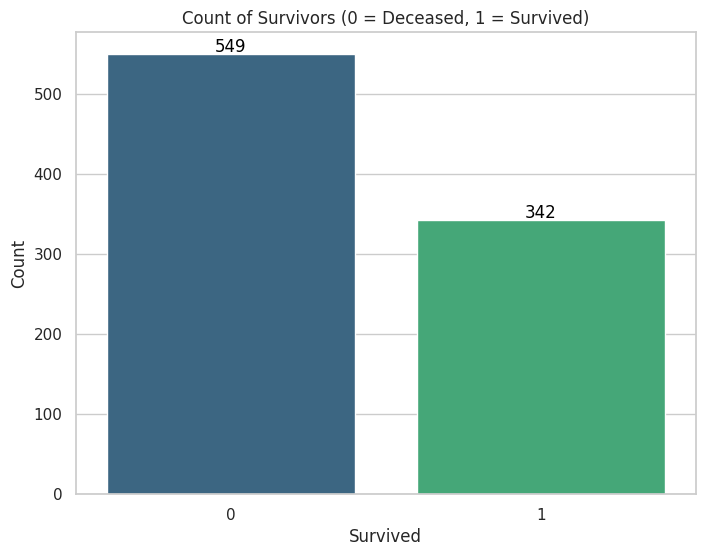

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style='whitegrid')

# 생존자 수 카운트 그래프 생성
plt.figure(figsize=(8, 6))
# FutureWarning 방지를 위해 hue에 x와 동일한 변수를 할당하고 legend를 해제합니다.
ax = sns.countplot(x='Survived', data=df, hue='Survived', palette='viridis', legend=False)

# 그래프 제목 및 라벨 설정
plt.title('Count of Survivors (0 = Deceased, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')

# 막대 위에 숫자 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [ ]:
# 원본 데이터를 활용해 Sex 컬럼 재설정 (남성: 0, 여성: 1)
temp_df = pd.read_csv('/content/6_titanic_data.csv')
df['Sex'] = temp_df['Sex'].map({'male': 0, 'female': 1})

# 결과 확인
print("Sex 컬럼 인코딩 복구 완료 (0: 남성, 1: 여성)")
display(df[['Sex']].head())

Sex 컬럼 인코딩 복구 완료 (0: 남성, 1: 여성)


,Sex
0,0
1,1
2,1
3,1
4,0


### 1. 특성 공학 (Feature Engineering)
`SibSp`와 `Parch`를 합쳐 전체 가족 구성원 수인 `FamilySize` 컬럼을 생성합니다.

In [ ]:
# 가족 구성원 수 컬럼 생성 (본인 포함 +1)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 결과 확인
display(df[['SibSp', 'Parch', 'FamilySize']].head())

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


### 2. 범주형 데이터 인코딩
`Embarked` 컬럼에 대해 원-핫 인코딩(One-Hot Encoding)을 수행합니다.

In [ ]:
# Embarked 컬럼 원-핫 인코딩
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')

# 결과 확인
display(df.filter(like='Embarked').head())

,Embarked_C,Embarked_Q,Embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


### 3. 데이터 스케일링
`Age`와 `Fare` 컬럼의 단위를 맞추기 위해 RobustScaler를 사용합니다. RobustScaler는 이상치에 강한 장점이 있습니다.

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# 스케일링 결과 확인
display(df[['Age', 'Fare']].describe())

,Age,Fare
count,8.910000e+02,891.000000
mean,2.153160e-16,0.768745
std,1.000155e+00,2.152200
min,-2.252240e+00,-0.626005
25%,-5.922398e-01,-0.283409
50%,0.000000e+00,0.000000
75%,4.077602e-01,0.716591
max,3.869299e+00,21.562738


### 4. 이상치(Outlier) 확인
`Fare` 컬럼에 대해 박스 플롯을 그려 이상치 분포를 확인합니다.

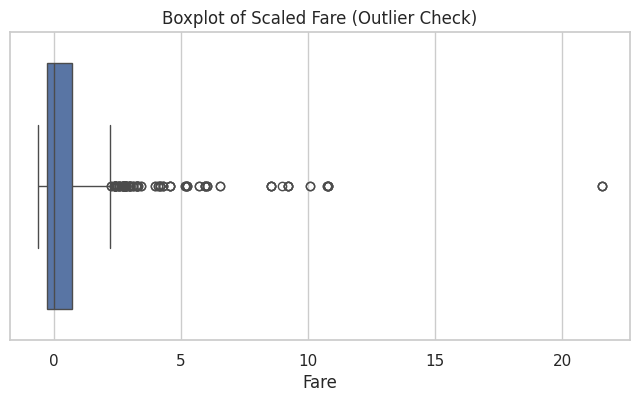

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Scaled Fare (Outlier Check)')
plt.show()

In [ ]:
# 최종 전처리된 데이터프레임 정보 확인
print("최종 데이터프레임 정보:")
display(df.info())
print("\n최종 데이터프레임 상위 5개 행:")
display(df.head())

최종 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  FamilySize   891 non-null    int64  
 12  Embarked_C   891 non-null    bool   
 13  Embarked_Q   891 non-null    bool   
 14  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(7), object(3)
memory usage: 86.3+ KB


None


최종 데이터프레임 상위 5개 행:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592240,1,0,A/5 21171,-0.312011,B96 B98,2,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638529,1,0,PC 17599,2.461242,C85,2,True,False,False
2,3,1,3,"Heikkinen, Miss Laina",1,-0.284548,0,0,STON/O2. 3101282,-0.282777,B96 B98,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407760,1,0,113803,1.673732,C123,2,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,0.407760,0,0,373450,-0.277363,B96 B98,1,False,False,True


In [ ]:
# 최종 전처리된 데이터프레임 정보 확인
print("최종 데이터프레임 정보:")
display(df.info())
print("\n최종 데이터프레임 상위 5개 행:")
display(df.head())

최종 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  FamilySize   891 non-null    int64  
 12  Embarked_C   891 non-null    bool   
 13  Embarked_Q   891 non-null    bool   
 14  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(7), object(3)
memory usage: 86.3+ KB


None


최종 데이터프레임 상위 5개 행:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592240,1,0,A/5 21171,-0.312011,B96 B98,2,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638529,1,0,PC 17599,2.461242,C85,2,True,False,False
2,3,1,3,"Heikkinen, Miss Laina",1,-0.284548,0,0,STON/O2. 3101282,-0.282777,B96 B98,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407760,1,0,113803,1.673732,C123,2,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,0.407760,0,0,373450,-0.277363,B96 B98,1,False,False,True


In [ ]:
# 최종 전처리된 데이터프레임 정보 확인
print("최종 데이터프레임 정보:")
display(df.info())
print("\n최종 데이터프레임 상위 5개 행:")
display(df.head())

최종 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  FamilySize   891 non-null    int64  
 12  Embarked_C   891 non-null    bool   
 13  Embarked_Q   891 non-null    bool   
 14  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(7), object(3)
memory usage: 86.3+ KB


None


최종 데이터프레임 상위 5개 행:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592240,1,0,A/5 21171,-0.312011,B96 B98,2,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638529,1,0,PC 17599,2.461242,C85,2,True,False,False
2,3,1,3,"Heikkinen, Miss Laina",1,-0.284548,0,0,STON/O2. 3101282,-0.282777,B96 B98,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407760,1,0,113803,1.673732,C123,2,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,0.407760,0,0,373450,-0.277363,B96 B98,1,False,False,True


In [ ]:
# 최종 전처리된 데이터프레임 구조 확인
print("최종 데이터프레임 정보:")
display(df.info())
print("\n최종 데이터프레임 상위 5개 행:")
display(df.head())

최종 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  FamilySize   891 non-null    int64  
 12  Embarked_C   891 non-null    bool   
 13  Embarked_Q   891 non-null    bool   
 14  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(7), object(3)
memory usage: 86.3+ KB


None


최종 데이터프레임 상위 5개 행:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592240,1,0,A/5 21171,-0.312011,B96 B98,2,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638529,1,0,PC 17599,2.461242,C85,2,True,False,False
2,3,1,3,"Heikkinen, Miss Laina",1,-0.284548,0,0,STON/O2. 3101282,-0.282777,B96 B98,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407760,1,0,113803,1.673732,C123,2,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,0.407760,0,0,373450,-0.277363,B96 B98,1,False,False,True


In [ ]:
# 분석 및 모델 학습에 불필요한 컬럼 삭제
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df.drop(columns=drop_cols, inplace=True)

# 결과 확인
print(f"삭제된 컬럼: {drop_cols}")
display(df.head())

삭제된 컬럼: ['PassengerId', 'Name', 'Ticket', 'Cabin']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,-0.592240,1,0,-0.312011,2,False,False,True
1,1,1,1,0.638529,1,0,2.461242,2,True,False,False
2,1,3,1,-0.284548,0,0,-0.282777,1,False,False,True
3,1,1,1,0.407760,1,0,1.673732,2,False,False,True
4,0,3,0,0.407760,0,0,-0.277363,1,False,False,True


### EDA 1: 변수 간 상관관계 분석
모든 수치형 변수들 간의 상관관계를 히트맵을 통해 시각화하여 'Survived'와 관련이 높은 특성을 찾습니다.

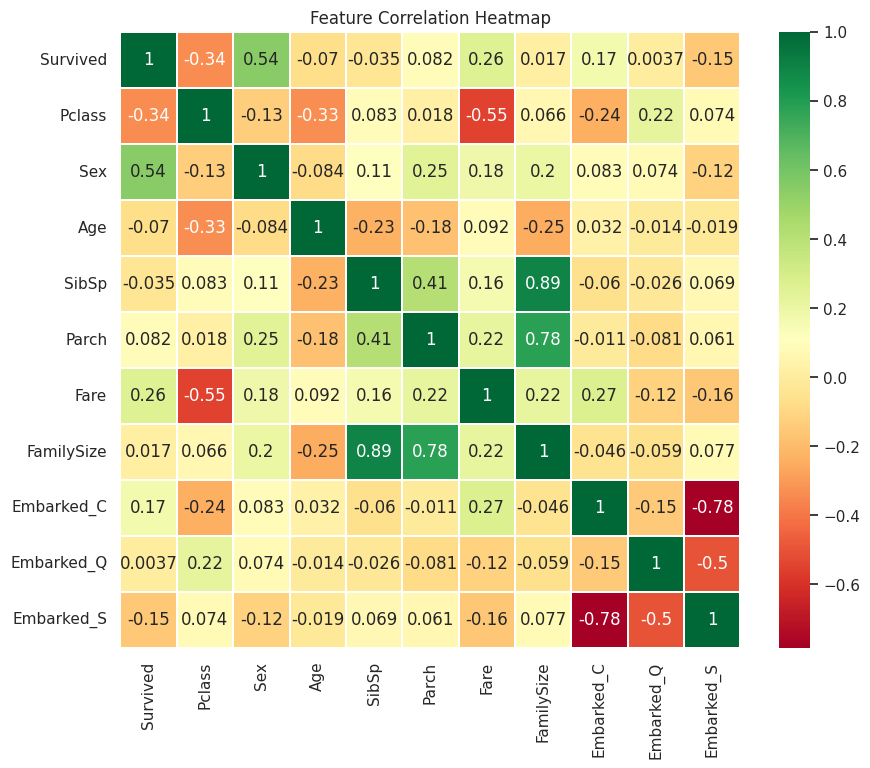

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', linewidths=0.2)
plt.title('Feature Correlation Heatmap')
plt.show()

### EDA 2: 주요 범주형 변수별 생존율 분석
성별(Sex)과 객실 등급(Pclass)에 따른 생존율 차이를 시각화합니다.

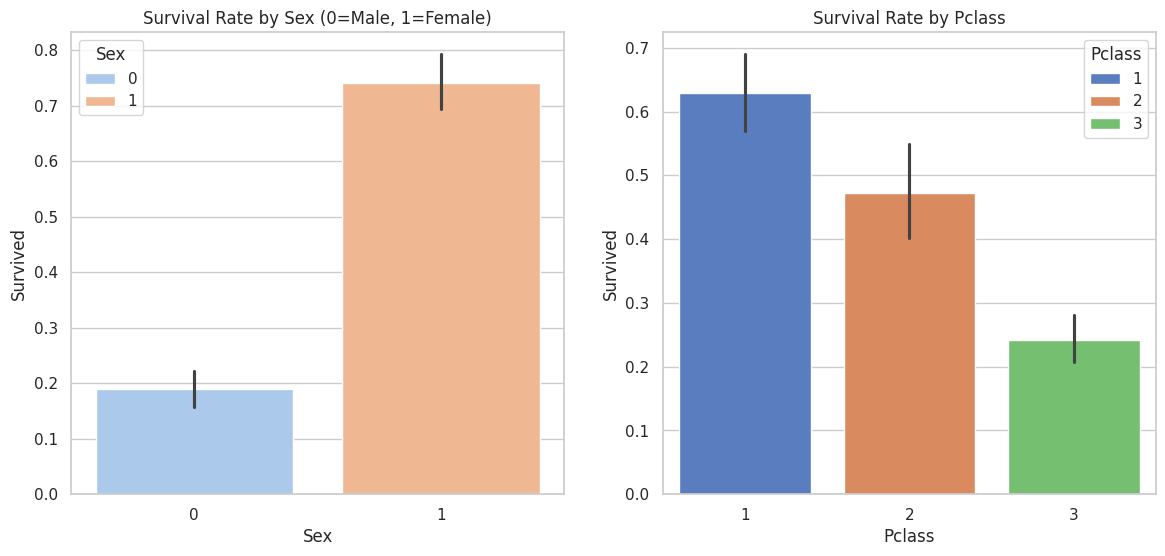

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 성별에 따른 생존율 (0: 남성, 1: 여성)
sns.barplot(x='Sex', y='Survived', data=df, ax=ax[0], palette='pastel', hue='Sex', legend=True)
ax[0].set_title('Survival Rate by Sex (0=Male, 1=Female)')

# 객실 등급에 따른 생존율
sns.barplot(x='Pclass', y='Survived', data=df, ax=ax[1], palette='muted', hue='Pclass', legend=True)
ax[1].set_title('Survival Rate by Pclass')

plt.show()

### EDA 3: 연령 및 가족 수에 따른 생존 분포
나이와 가족 구성원 수가 생존에 어떤 영향을 주는지 살펴봅니다.

### 객실 등급(Pclass)과 생존(Survived) 간의 통계적 유의성 검정
카이제곱 검정을 통해 객실 등급에 따른 생존율 차이가 통계적으로 유의미한지 분석합니다.

In [ ]:
from scipy.stats import chi2_contingency

# 1. 교차표(Contingency Table) 생성
contingency_table = pd.crosstab(df['Pclass'], df['Survived'])
print("--- 객실 등급별 생존 현황 (교차표) ---")
display(contingency_table)

# 2. 카이제곱 검정 수행
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\n카이제곱 통계량: {chi2:.4f}")
print(f"p-value: {p:.4e}")

# 3. 결과 해석
if p < 0.05:
    print("\n결과 해석: p-value가 0.05보다 작으므로, 객실 등급에 따른 생존율 차이는 통계적으로 매우 유의미합니다.")
else:
    print("\n결과 해석: p-value가 0.05보다 크므로, 객실 등급에 따른 생존율 차이가 통계적으로 유의미하다고 보기 어렵습니다.")

--- 객실 등급별 생존 현황 (교차표) ---


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119



카이제곱 통계량: 102.8890
p-value: 4.5493e-23

결과 해석: p-value가 0.05보다 작으므로, 객실 등급에 따른 생존율 차이는 통계적으로 매우 유의미합니다.


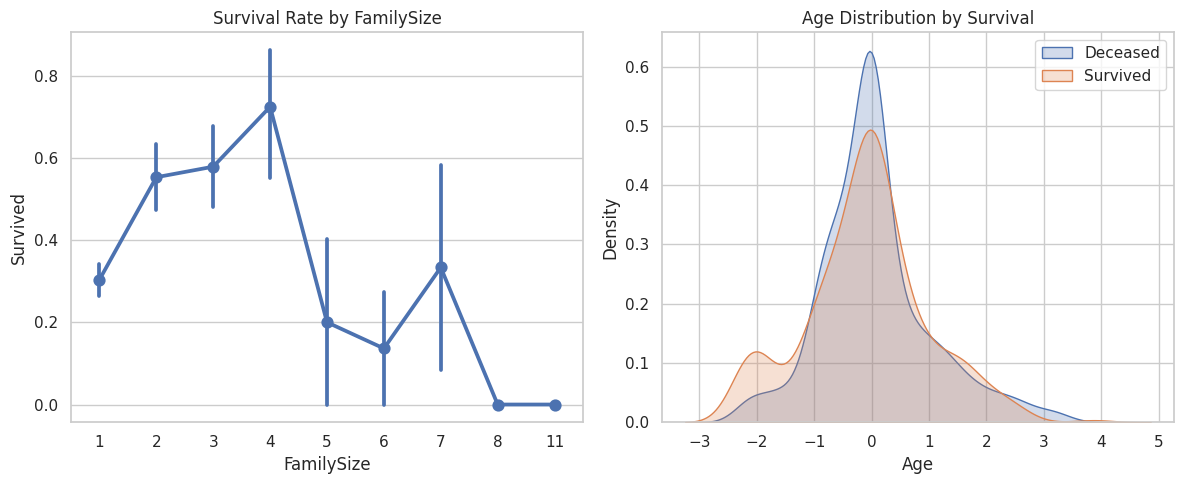

In [ ]:
plt.figure(figsize=(12, 5))

# 가족 수별 생존율
plt.subplot(1, 2, 1)
sns.pointplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival Rate by FamilySize')

# 연령대별 생존 KDE Plot
plt.subplot(1, 2, 2)
sns.kdeplot(df.loc[df['Survived'] == 0, 'Age'], label='Deceased', fill=True)
sns.kdeplot(df.loc[df['Survived'] == 1, 'Age'], label='Survived', fill=True)
plt.title('Age Distribution by Survival')
plt.legend()

plt.tight_layout()
plt.show()

### 연령(Age)과 생존(Survived) 간의 통계적 분석
점-이연 상관계수와 로지스틱 회귀 분석을 통해 연령이 생존에 미치는 영향을 수치적으로 확인합니다.

In [ ]:
from scipy.stats import pointbiserialr
import statsmodels.api as sm

# 1. 점-이연 상관계수 분석
pb_corr, pb_p_value = pointbiserialr(df['Survived'], df['Age'])

print("--- 점-이연 상관계수 분석 ---")
print(f"상관계수: {pb_corr:.4f}")
print(f"p-value: {pb_p_value:.4f}")

# 2. 로지스틱 회귀 분석 (통계적 유의성 검정)
# 독립 변수에 상수항 추가
X = sm.add_constant(df['Age'])
y = df['Survived']

logit_model = sm.Logit(y, X)
result = logit_model.fit()

print("\n--- 로지스틱 회귀 분석 요약 ---")
print(result.summary())

# 3. 결과 해석
print("\n[결과 해석]")
if pb_p_value < 0.05:
    direction = "음(-)" if pb_corr < 0 else "양(+)"
    print(f"연령과 생존율 사이에는 통계적으로 유의미한 {direction}의 상관관계가 존재합니다.")
    print("나이가 많을수록 생존 확률이 낮아지는 경향이 있음을 시사합니다.")
else:
    print("연령과 생존율 사이의 상관관계는 통계적으로 유의미하지 않습니다.")

--- 점-이연 상관계수 분석 ---
상관계수: -0.0698
p-value: 0.0372
Optimization terminated successfully.
         Current function value: 0.663456
         Iterations 4

--- 로지스틱 회귀 분석 요약 ---
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      889
Method:                           MLE   Df Model:                            1
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                0.003688
Time:                        08:25:47   Log-Likelihood:                -591.14
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                   0.03643
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4758      0.069  

### 상관계수 히트맵 시각화
피어슨 상관계수를 활용하여 각 변수 간의 관계를 수치화하고 시각화합니다.

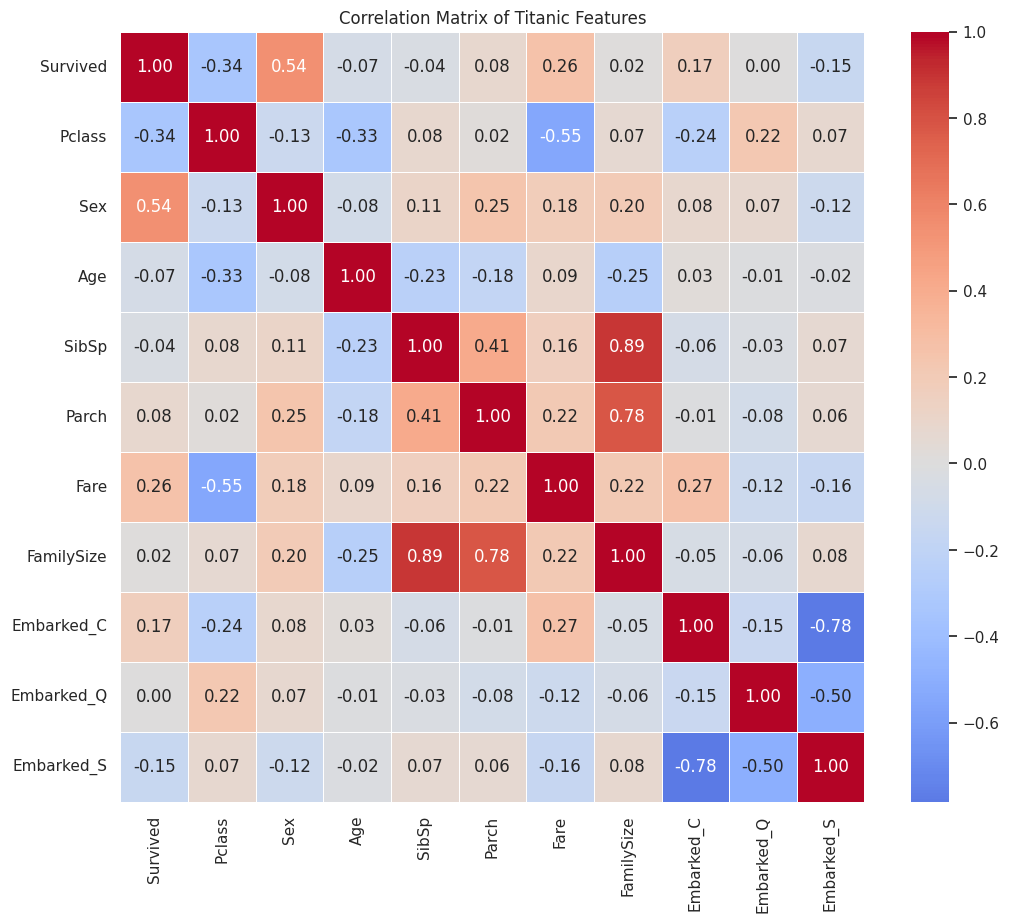

In [ ]:
# 모든 열이 수치형인지 확인 후 상관계수 계산
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Titanic Features')
plt.show()

### 다중공선성 검토 및 변수 정리
`FamilySize`는 `SibSp`(형제/자매/배우자 수)와 `Parch`(부모/자녀 수)를 기반으로 생성된 변수입니다. 이들은 강한 상관관계를 가지므로, 분석의 단순화를 위해 원본 변수인 `SibSp`와 `Parch`를 제거하고 합산된 `FamilySize`만 유지하도록 하겠습니다.

상관관계가 높은(0.7 초과) 변수 후보: ['FamilySize', 'Embarked_S']
삭제된 중복 변수: ['SibSp', 'Parch']


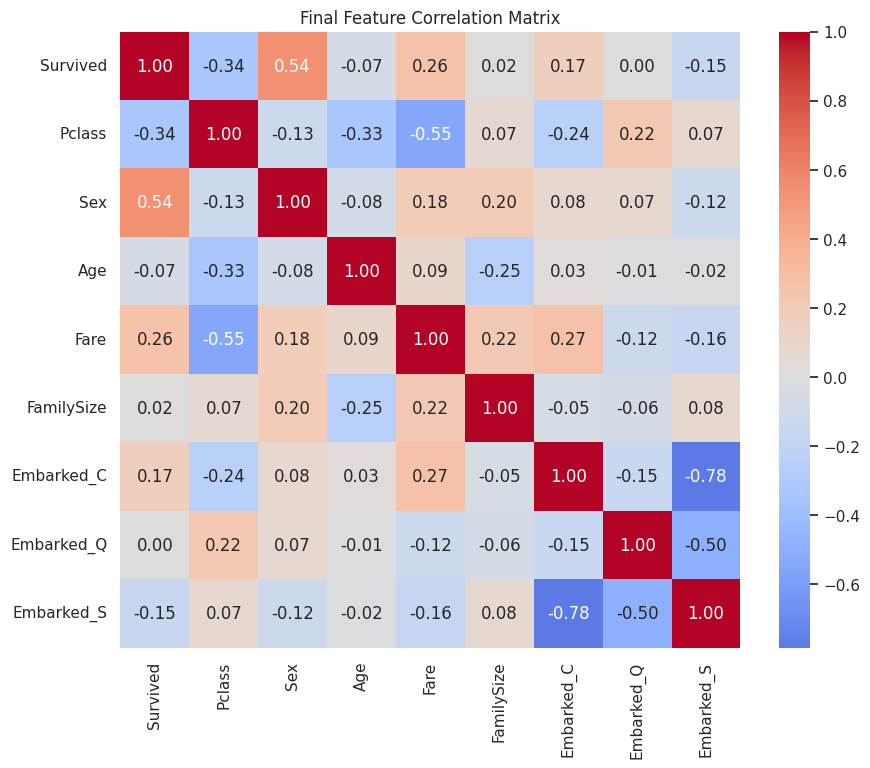

In [ ]:
import numpy as np

# 높은 상관관계를 가지는 변수 쌍 확인 (절대값 0.7 이상)
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper.columns if any(upper[column] > 0.7)]

print(f"상관관계가 높은(0.7 초과) 변수 후보: {high_corr}")

# 다중공선성 해결을 위해 SibSp와 Parch 삭제 (FamilySize로 통합되었으므로)
drop_redundant = ['SibSp', 'Parch']
df.drop(columns=drop_redundant, inplace=True)

print(f"삭제된 중복 변수: {drop_redundant}")

# 최종 변수들 간의 상관계수 재확인
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Final Feature Correlation Matrix')
plt.show()

### 객실 등급(Pclass)별 연령(Age) 평균 차이 분석 (ANOVA)
각 객실 등급 그룹 간에 연령의 평균이 통계적으로 유의미한 차이를 보이는지 검정합니다.

--- 객실 등급별 연령 ANOVA 분석 결과 ---
F-통계량: 56.5744
p-value: 7.4812e-24


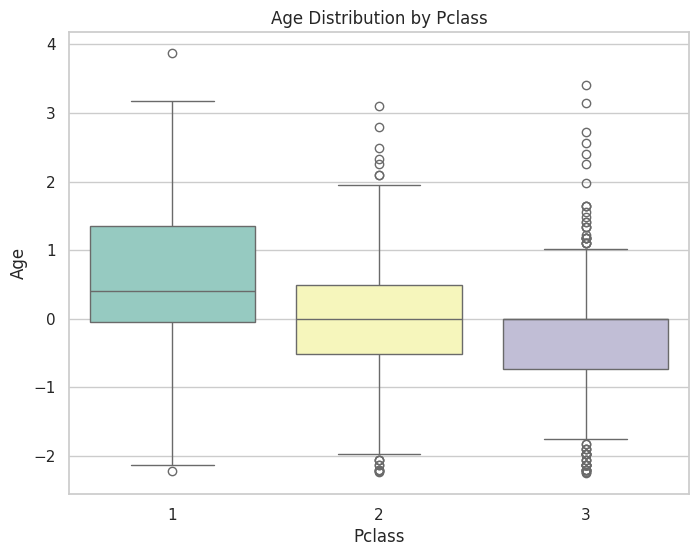


결과 해석: p-value가 7.4812e-24로 0.05보다 작으므로, 객실 등급별로 평균 연령에 통계적으로 유의미한 차이가 있습니다.


In [ ]:
from scipy.stats import f_oneway

# 1. 집단별 데이터 분리
group1 = df[df['Pclass'] == 1]['Age']
group2 = df[df['Pclass'] == 2]['Age']
group3 = df[df['Pclass'] == 3]['Age']

# 2. ANOVA 수행
f_stats, p_value = f_oneway(group1, group2, group3)

print("--- 객실 등급별 연령 ANOVA 분석 결과 ---")
print(f"F-통계량: {f_stats:.4f}")
print(f"p-value: {p_value:.4e}")

# 3. 시각화로 확인
plt.figure(figsize=(8, 6))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set3', hue='Pclass', legend=False)
plt.title('Age Distribution by Pclass')
plt.show()

# 4. 결과 해석
if p_value < 0.05:
    print(f"\n결과 해석: p-value가 {p_value:.4e}로 0.05보다 작으므로, 객실 등급별로 평균 연령에 통계적으로 유의미한 차이가 있습니다.")
else:
    print("\n결과 해석: p-value가 0.05보다 크므로, 객실 등급별 평균 연령 차이가 통계적으로 유의미하지 않습니다.")

### 선형 회귀 분석 (Linear Probability Model)
다중 선형 회귀를 통해 각 특성(Pclass, Sex, Age, Fare, FamilySize 등)이 생존 확률에 미치는 가중치를 분석합니다.

--- 타이타닉 생존 요인 선형 회귀 분석 결과 ---
                            OLS Regression Results                            
Dep. Variable:               Survived   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     83.24
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           8.63e-93
Time:                        08:27:37   Log-Likelihood:                -396.21
No. Observations:                 891   AIC:                             808.4
Df Residuals:                     883   BIC:                             846.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6387

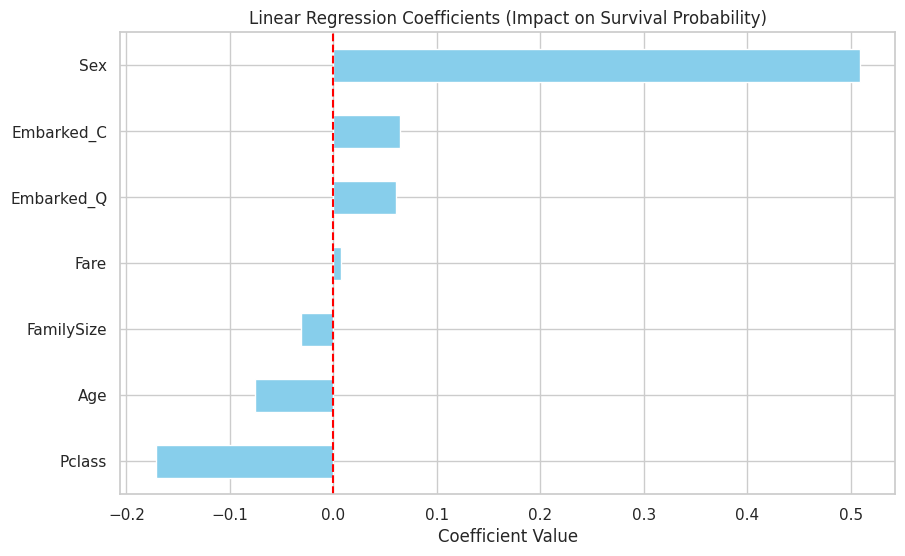

In [ ]:
import statsmodels.api as sm

# 1. 독립 변수(X)와 종속 변수(y) 설정
# 불필요한 범주형 변수를 제외하고 수치화된 변수들만 선택합니다.
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'Embarked_C', 'Embarked_Q']
X = df[features].astype(float)
y = df['Survived'].astype(float)

# 2. 상수항(Intercept) 추가
X = sm.add_constant(X)

# 3. 선형 회귀 모델 적합 (OLS)
linear_model = sm.OLS(y, X)
results = linear_model.fit()

# 4. 결과 출력
print("--- 타이타닉 생존 요인 선형 회귀 분석 결과 ---")
print(results.summary())

# 5. 계수 시각화
plt.figure(figsize=(10, 6))
coeffs = results.params[1:].sort_values()
coeffs.plot(kind='barh', color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Linear Regression Coefficients (Impact on Survival Probability)')
plt.xlabel('Coefficient Value')
plt.show()

### 다변량 로지스틱 회귀 분석 (Multivariate Logistic Regression)
여러 독립 변수를 동시에 고려하여 생존에 미치는 영향을 분석합니다.

In [ ]:
import statsmodels.api as sm

# 1. 독립 변수(X)와 종속 변수(y) 설정
# 분석에 사용할 주요 특성들 선택
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'Embarked_C', 'Embarked_Q']
X = df[features].astype(float)
y = df['Survived'].astype(float)

# 2. 상수항(Intercept) 추가
X = sm.add_constant(X)

# 3. 로지스틱 회귀 모델 적합
logit_model = sm.Logit(y, X)
logit_results = logit_model.fit()

# 4. 결과 출력
print("--- 타이타닉 생존 요인 로지스틱 회귀 분석 결과 ---")
print(logit_results.summary())

# 5. 오즈비(Odds Ratio) 계산 및 출력
# 오즈비는 해당 변수가 1단위 증가할 때 생존 '확률 대비 불확실성'이 몇 배가 되는지 나타냅니다.
odds_ratios = np.exp(logit_results.params)
print("\n--- 변수별 오즈비 (Odds Ratio) ---")
display(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.441326
         Iterations 6
--- 타이타닉 생존 요인 로지스틱 회귀 분석 결과 ---
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      883
Method:                           MLE   Df Model:                            7
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.3373
Time:                        08:29:22   Log-Likelihood:                -393.22
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 2.148e-82
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1920      0.343      3.471      0.001       0.519       1.

,0
const,3.293790
Pclass,0.334627
Sex,15.582650
Age,0.602008
Fare,1.050239
FamilySize,0.800386
Embarked_C,1.534024
Embarked_Q,1.437944


### 로지스틱 회귀 계수 시각화
모델의 계수(Log-Odds)를 시각화하여 변수별 영향력의 방향과 크기를 확인합니다.

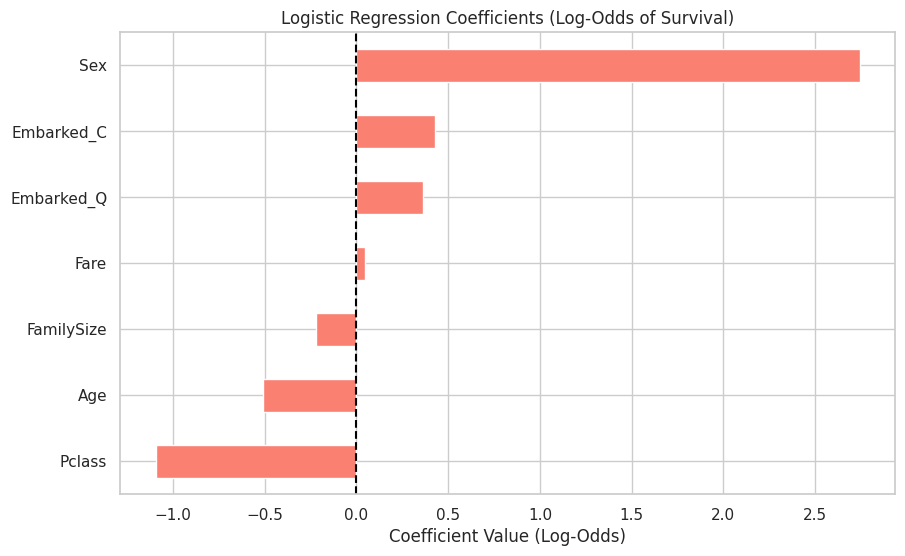

In [ ]:
plt.figure(figsize=(10, 6))
# 상수항을 제외한 계수들 정렬
logit_coeffs = logit_results.params[1:].sort_values()
logit_coeffs.plot(kind='barh', color='salmon')
plt.axvline(0, color='black', linestyle='--')
plt.title('Logistic Regression Coefficients (Log-Odds of Survival)')
plt.xlabel('Coefficient Value (Log-Odds)')
plt.show()

회귀분석에서 모형이 통계적으로 적합한지. ★★★

### 로지스틱 회귀 분석 결과 시각화 (오즈비)
오즈비(Odds Ratio)는 변수가 1단위 증가할 때 생존 확률이 몇 배가 되는지를 나타냅니다. 1보다 크면 긍정적, 1보다 작으면 부정적 영향을 의미합니다.

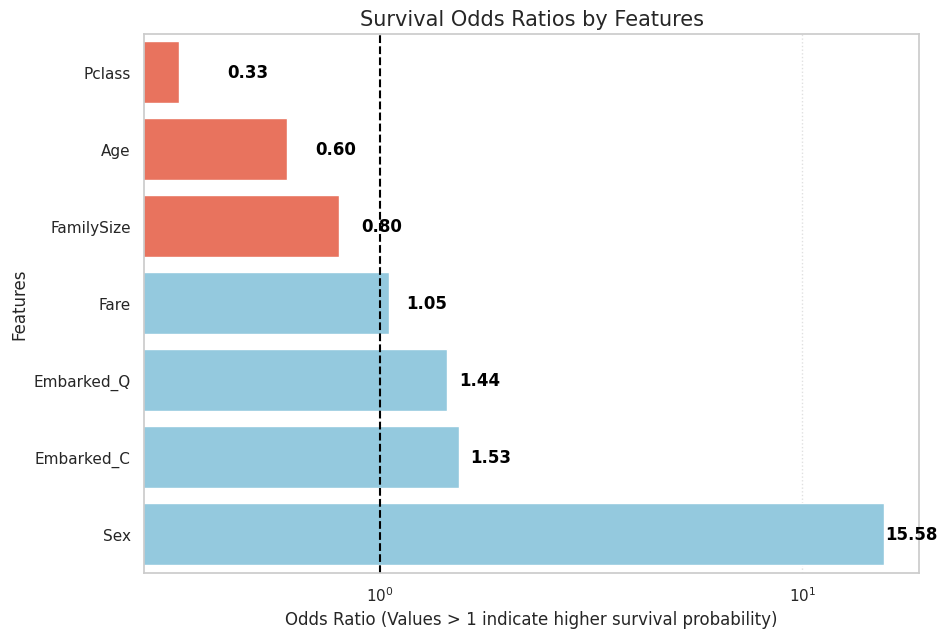

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 오즈비 데이터 준비 (상수항 제외)
or_df = odds_ratios.drop('const').sort_values()

# 2. 시각화
plt.figure(figsize=(10, 7))
colors = ['tomato' if val < 1 else 'skyblue' for val in or_df.values]
ax = sns.barplot(x=or_df.values, y=or_df.index, palette=colors, hue=or_df.index, legend=False)

# 기준선 (1.0) 추가
plt.axvline(x=1, color='black', linestyle='--', linewidth=1.5)

# 막대 끝에 수치 표시
for i, v in enumerate(or_df.values):
    ax.text(v + 0.1, i, f'{v:.2f}', color='black', va='center', fontweight='bold')

plt.title('Survival Odds Ratios by Features', fontsize=15)
plt.xlabel('Odds Ratio (Values > 1 indicate higher survival probability)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xscale('log') # 값의 차이가 크므로 로그 스케일 적용
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

#### **그래프 읽는 법**
*   **Sex (15.58):** 여성이 남성보다 생존 오즈가 약 15.6배 높습니다. (압도적 영향)
*   **Embarked_C/Q:** 다른 항구 대비 생존 오즈가 약 1.4~1.5배 높습니다.
*   **Pclass (0.33):** 등급 수치가 커질수록(1등석->3등석) 생존 오즈가 1/3 수준으로 감소합니다.
*   **Age/FamilySize:** 수치가 높을수록 생존 오즈가 1 미만으로 떨어져 부정적인 영향을 줍니다.

### 5. 머신러닝 모델 구축 (Random Forest)
학습 데이터를 분리하고 랜덤 포레스트 분류기를 사용하여 생존 예측 모델을 생성합니다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. 특성(X)과 타겟(y) 분리
X = df[features]  # 이전에 정의된 features 리스트 사용
y = df['Survived']

# 2. 학습 데이터와 테스트 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 모델 생성 및 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. 예측 수행
y_pred = rf_model.predict(X_test)

# 5. 모델 평가 결과 출력
print("--- 모델 평가 결과 ---")
print(f"정확도 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\n[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred))
print("\n[Classification Report]")
print(classification_report(y_test, y_pred))

--- 모델 평가 결과 ---
정확도 (Accuracy): 0.8101

[Confusion Matrix]
[[90 15]
 [19 55]]

[Classification Report]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



### 모델의 특성 중요도 (Feature Importance) 시각화
예측 모델이 생존 여부를 판단할 때 어떤 변수를 가장 중요하게 고려했는지 확인합니다.

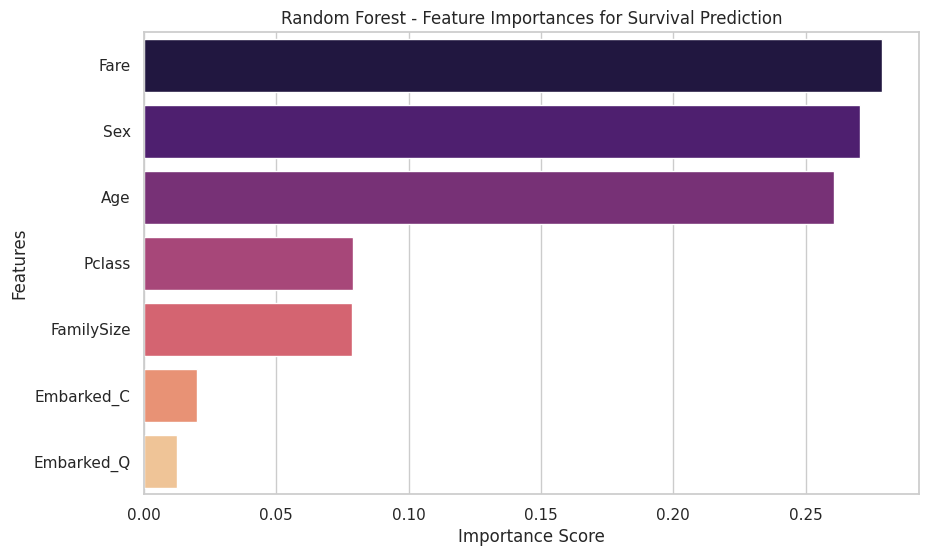

In [ ]:
import pandas as pd

# 특성 중요도 추출
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='magma', hue=importances.index, legend=False)
plt.title('Random Forest - Feature Importances for Survival Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### 5. 머신러닝 생존 예측 모델 구축
랜덤 포레스트(Random Forest) 알고리즘을 사용하여 생존 여부를 예측하고 모델의 정확도를 평가합니다.

### 모델의 특성 중요도 (Feature Importance) 시각화
예측 모델이 생존 여부를 판단할 때 어떤 변수를 가장 중요하게 고려했는지 확인합니다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 특성(X)과 타겟(y) 설정
# 분석에서 유의미했던 변수들을 선택합니다.
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'Embarked_C', 'Embarked_Q']
X = df[features]
y = df['Survived']

# 2. 데이터 분할 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 모델 생성 및 학습
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 4. 예측 및 결과 보고
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"[모델 예측 정확도]: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\n--- 상세 평가 지표 ---")
print(classification_report(y_test, y_pred))

[모델 예측 정확도]: 0.8045 (80.45%)

--- 상세 평가 지표 ---
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



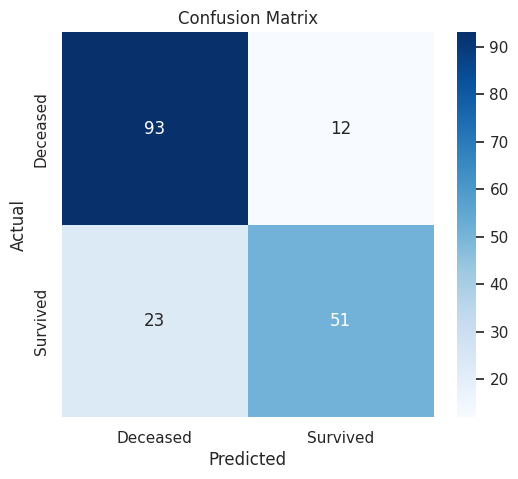

In [ ]:
# 혼동 행렬 시각화
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Deceased', 'Survived'],
            yticklabels=['Deceased', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()